In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [26]:
# define your state
class BMIState(TypedDict):

    weight_kg: float
    height_mtr: float
    bmi: float
    fittness: str

In [27]:
# type hinting
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_mtr']

    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)

    return state

In [30]:
def find_fittness(state: BMIState) -> BMIState:
    bmi = state['bmi']
    
    if bmi < 18.5:
        state['fittness'] = 'Underweight'
    elif 18.5 <= bmi < 25.0:
        state['fittness'] = 'Fit'
    elif 25.0 <= bmi < 30.0:
        state['fittness'] = 'Unfit'
    else:
        state['fittness'] = 'Obese'

    return state

In [33]:
# define your graph
graph = StateGraph(BMIState)

# add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('find_fittness', find_fittness)

# add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi','find_fittness')
graph.add_edge('find_fittness', END)

# compile the graph
workflow = graph.compile()

In [34]:
# exceute the graph
result = workflow.invoke({'weight_kg':80, 'height_mtr':1.73})

In [35]:
print("BMI is", result['bmi'])

BMI is 26.73


In [36]:
print("Fitness is", result['fittness'])

Fitness is Unfit


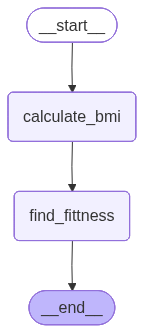

In [37]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())